# Crop Recommendation Model Selection and Evaluation

This notebook compares baseline, candidate, and tuned classification models for crop recommendation using the processed train/test split.

## Workflow

1. Load the processed crop feature and target files.
2. Benchmark baseline and candidate classifiers with 5-fold stratified cross-validation.
3. Tune the top two models with 3-fold GridSearchCV.
4. Compare the tuned models and evaluate the final choice on the holdout test set.

In [3]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = ROOT / 'outputs'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_TRAIN_PATH = DATA_DIR / 'crop_X_train.csv'
X_TEST_PATH = DATA_DIR / 'crop_X_test.csv'
Y_TRAIN_PATH = DATA_DIR / 'crop_y_train.csv'
Y_TEST_PATH = DATA_DIR / 'crop_y_test.csv'

In [4]:
# Load processed data
X_train = pd.read_csv(X_TRAIN_PATH)
X_test  = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test  = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Unique classes: {y_train.nunique()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_pipeline(model, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

def evaluate_model(name, estimator):
    start = time.perf_counter()
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_macro',
            'recall': 'recall_macro',
            'f1': 'f1_macro',
        },
        n_jobs=1,
        return_train_score=False,
    )
    elapsed = time.perf_counter() - start
    return {
        'model': name,
        'accuracy': scores['test_accuracy'].mean(),
        'precision_macro': scores['test_precision'].mean(),
        'recall_macro': scores['test_recall'].mean(),
        'f1_macro': scores['test_f1'].mean(),
        'fit_time_mean_sec': scores['fit_time'].mean(),
        'cv_elapsed_sec': elapsed,
    }

n_classes = y_train.nunique()

Train size: (82140, 7), Test size: (20535, 7)
Unique classes: 111


In [5]:
models = {
    'DummyClassifier': build_pipeline(DummyClassifier(strategy='most_frequent')),
    'LogisticRegression': build_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE), scale=True),
    'RandomForestClassifier': build_pipeline(RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_leaf=5,
        max_leaf_nodes=256,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
    'XGBClassifier': build_pipeline(XGBClassifier(
        objective='multi:softprob',
        num_class=n_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        n_estimators=120,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
    'SVC_rbf': build_pipeline(SVC(kernel='rbf', C=10, gamma='scale')),
    'KNN': build_pipeline(KNeighborsClassifier(n_neighbors=7), scale=True),
    'ExtraTreesClassifier': build_pipeline(ExtraTreesClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_leaf=5,
        max_leaf_nodes=256,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
}

baseline_results = []
for name, estimator in models.items():
    baseline_results.append(evaluate_model(name, estimator))

results_df = pd.DataFrame(baseline_results).sort_values(['f1_macro', 'accuracy'], ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(RESULTS_DIR / 'crop_model_selection_cv_results.csv', index=False)

d:\PROJECTS\AGRICULTURE\FarmIntel\ml-models\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\AGRICULTURE\FarmIntel\ml-models\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\AGRICULTURE\FarmIntel\ml-models\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

,model,accuracy,precision_macro,recall_macro,f1_macro,fit_time_mean_sec,cv_elapsed_sec
0,XGBClassifier,0.852204,0.842872,0.852204,0.844352,139.459478,719.195038
1,KNN,0.676978,0.615514,0.676978,0.630776,0.093821,4.078642
2,ExtraTreesClassifier,0.628318,0.734196,0.628318,0.527110,1.209796,9.833357
3,RandomForestClassifier,0.481385,0.675742,0.481385,0.462159,7.813343,42.795624
4,SVC_rbf,0.294022,0.165873,0.294022,0.199289,202.594518,2297.952533
5,LogisticRegression,0.170234,0.073955,0.170234,0.099818,12.667743,63.559172
6,DummyClassifier,0.009009,0.000081,0.009009,0.000161,0.010748,0.253907


In [8]:
import itertools, time
from tqdm.auto import tqdm
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv2 = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

def manual_search(name, base_estimator, param_grid, X, y, cv):
    keys = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    best_score, best_params, results = -1, {}, []
    print(f'\n[{name}] {len(combos)} param combos x {cv.n_splits} folds', flush=True)
    bar = tqdm(combos, desc=name, unit='combo', ncols=90)
    for combo in bar:
        params = dict(zip(keys, combo))
        est = base_estimator.set_params(**params)
        t0 = time.perf_counter()
        scores = cross_val_score(est, X, y, cv=cv, scoring='f1_macro', n_jobs=1)
        elapsed = time.perf_counter() - t0
        mean_f1 = scores.mean()
        short = {k.split('__')[-1]: v for k, v in params.items()}
        bar.set_postfix({'f1': f'{mean_f1:.4f}', 'best': f'{best_score:.4f}', 's': f'{elapsed:.0f}'})
        tqdm.write(f'  {short}  ->  f1={mean_f1:.4f}  [{elapsed:.1f}s]', end='\n')
        results.append({'params': params, 'mean_f1': mean_f1, 'std_f1': scores.std(), 'elapsed': elapsed})
        if mean_f1 > best_score:
            best_score, best_params = mean_f1, params
    bar.close()
    print(f'\nBest {name}: {best_params}', flush=True)
    print(f'Best F1 macro: {best_score:.4f}', flush=True)
    return best_params, best_score, results

# ── RF screening ─────────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [8, 16],
}
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_best_params, rf_best_score, rf_results = manual_search(
    'RandomForest', rf_base, rf_param_grid, X_train, y_train, cv2
)

# ── XGB screening ─────────────────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6],
    'learning_rate': [0.05, 0.1],
}
xgb_base = XGBClassifier(
    objective='multi:softprob', num_class=n_classes,
    eval_metric='mlogloss', tree_method='hist',
    random_state=RANDOM_STATE, n_jobs=1,
)
xgb_best_params, xgb_best_score, xgb_results = manual_search(
    'XGBoost', xgb_base, xgb_param_grid, X_train, y_train, cv2
)

# ── Summary table ─────────────────────────────────────────────────────────────
all_results = (
    [{'model': 'RF',  **r} for r in rf_results] +
    [{'model': 'XGB', **r} for r in xgb_results]
)
summary_df = pd.DataFrame(all_results).sort_values('mean_f1', ascending=False)
summary_df['short_params'] = summary_df['params'].apply(
    lambda p: str({k.split('__')[-1]: v for k, v in p.items()})
)
display(summary_df[['model', 'short_params', 'mean_f1', 'std_f1', 'elapsed']].reset_index(drop=True))


[RandomForest] 6 param combos x 2 folds


RandomForest:   0%|                                              | 0/6 [00:00<?, ?combo/s]

  {'n_estimators': 50, 'max_depth': 8}  ->  f1=0.3095  [5.7s]
  {'n_estimators': 50, 'max_depth': 16}  ->  f1=0.6796  [9.4s]
  {'n_estimators': 100, 'max_depth': 8}  ->  f1=0.3182  [11.3s]
  {'n_estimators': 100, 'max_depth': 16}  ->  f1=0.6939  [18.8s]
  {'n_estimators': 200, 'max_depth': 8}  ->  f1=0.3309  [21.9s]
  {'n_estimators': 200, 'max_depth': 16}  ->  f1=0.7019  [37.3s]

Best RandomForest: {'n_estimators': 200, 'max_depth': 16}
Best F1 macro: 0.7019

[XGBoost] 8 param combos x 2 folds


XGBoost:   0%|                                                   | 0/8 [00:00<?, ?combo/s]

  {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}  ->  f1=0.6027  [101.8s]
  {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}  ->  f1=0.6785  [61.1s]
  {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05}  ->  f1=0.7211  [74.8s]
  {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}  ->  f1=0.7925  [75.4s]
  {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}  ->  f1=0.6756  [119.3s]
  {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}  ->  f1=0.7553  [119.2s]
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}  ->  f1=0.7903  [146.4s]
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}  ->  f1=0.8528  [144.4s]

Best XGBoost: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Best F1 macro: 0.8528


,model,short_params,mean_f1,std_f1,elapsed
0,XGB,"{'n_estimators': 200, 'max_depth': 6, 'learnin...",0.852791,0.000030,144.404344
1,XGB,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.792516,0.000498,75.431993
2,XGB,"{'n_estimators': 200, 'max_depth': 6, 'learnin...",0.790292,0.001869,146.392962
3,XGB,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",0.755264,0.000315,119.174838
4,XGB,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.721105,0.001050,74.781819
5,RF,"{'n_estimators': 200, 'max_depth': 16}",0.701917,0.000593,37.255501
6,RF,"{'n_estimators': 100, 'max_depth': 16}",0.693851,0.005259,18.827170
7,RF,"{'n_estimators': 50, 'max_depth': 16}",0.679612,0.008982,9.378950
8,XGB,"{'n_estimators': 100, 'max_depth': 4, 'learnin...",0.678501,0.003983,61.060855
9,XGB,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",0.675585,0.003689,119.332804


## Hyperparameter Tuning

The next cell tunes the two strongest tree-based candidates with 3-fold cross-validation.

In [9]:
# Refined tuning around the best params found in Cell 5
best_rf_n_est = rf_best_params.get('n_estimators', 200)
best_rf_depth = rf_best_params.get('max_depth', 16)
best_xgb_n_est = xgb_best_params.get('n_estimators', 200)
best_xgb_depth = xgb_best_params.get('max_depth', 6)
best_xgb_lr = xgb_best_params.get('learning_rate', 0.1)

# ── RF refined ───────────────────────────────────────────────────────────────
rf_refined_grid = {
    'n_estimators':    [best_rf_n_est, best_rf_n_est * 2, best_rf_n_est * 3],
    'max_depth':       [best_rf_depth, None],
    'min_samples_leaf':[1, 2],
}
rf_base2 = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
rf_best_params, rf_best_score, rf_results2 = manual_search(
    'RandomForest-Tuned', rf_base2, rf_refined_grid, X_train, y_train, cv2
)

# ── XGB refined ──────────────────────────────────────────────────────────────
xgb_refined_grid = {
    'n_estimators':    [best_xgb_n_est, best_xgb_n_est * 2],
    'max_depth':       [best_xgb_depth],
    'learning_rate':   [best_xgb_lr],
    'subsample':       [0.8, 0.9],
    'colsample_bytree':[0.8, 0.9],
}
xgb_base2 = XGBClassifier(
    objective='multi:softprob', num_class=n_classes,
    eval_metric='mlogloss', tree_method='hist',
    random_state=RANDOM_STATE, n_jobs=1,
)
xgb_best_params, xgb_best_score, xgb_results2 = manual_search(
    'XGBoost-Tuned', xgb_base2, xgb_refined_grid, X_train, y_train, cv2
)

# ── Build best estimators for downstream cells ────────────────────────────────
rf_search = type('R', (), {'best_params_': {f'model__{k}': v for k,v in rf_best_params.items()},
                           'best_score_': rf_best_score,
                           'best_estimator_': build_pipeline(RandomForestClassifier(
                               **rf_best_params, random_state=RANDOM_STATE, n_jobs=1))})() 
xgb_search = type('X', (), {'best_params_': {f'model__{k}': v for k,v in xgb_best_params.items()},
                             'best_score_': xgb_best_score,
                             'best_estimator_': build_pipeline(XGBClassifier(
                                 **xgb_best_params,
                                 objective='multi:softprob', num_class=n_classes,
                                 eval_metric='mlogloss', tree_method='hist',
                                 random_state=RANDOM_STATE, n_jobs=1))})() 
print('Best RF  :', rf_best_params,  '| F1:', round(rf_best_score, 4), flush=True)
print('Best XGB :', xgb_best_params, '| F1:', round(xgb_best_score, 4), flush=True)


[RandomForest-Tuned] 12 param combos x 2 folds


RandomForest-Tuned:   0%|                                       | 0/12 [00:00<?, ?combo/s]

  {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 1}  ->  f1=0.7019  [39.7s]
  {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 2}  ->  f1=0.6791  [45.2s]
  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}  ->  f1=0.8902  [90.0s]
  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2}  ->  f1=0.8879  [83.2s]
  {'n_estimators': 400, 'max_depth': 16, 'min_samples_leaf': 1}  ->  f1=0.7044  [95.7s]
  {'n_estimators': 400, 'max_depth': 16, 'min_samples_leaf': 2}  ->  f1=0.6864  [92.4s]
  {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1}  ->  f1=0.8904  [223.0s]
  {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 2}  ->  f1=0.8878  [315.5s]
  {'n_estimators': 600, 'max_depth': 16, 'min_samples_leaf': 1}  ->  f1=0.7020  [124.8s]
  {'n_estimators': 600, 'max_depth': 16, 'min_samples_leaf': 2}  ->  f1=0.6893  [107.9s]
  {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1}  ->  f1=0.8906  [205.4s]
  {'n_estimators'

XGBoost-Tuned:   0%|                                             | 0/8 [00:00<?, ?combo/s]

  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}  ->  f1=0.8660  [238.9s]
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.9}  ->  f1=0.8684  [239.0s]
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.8}  ->  f1=0.8641  [224.6s]
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9}  ->  f1=0.8660  [226.5s]
  {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}  ->  f1=0.8877  [451.3s]
  {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.9}  ->  f1=0.8875  [455.0s]
  {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.8}  ->  f1=0.8872  [1266.7s]
  {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsampl

In [10]:
tuned_candidates = {
    'RandomForest_tuned': rf_search.best_estimator_,
    'XGBoost_tuned': xgb_search.best_estimator_,
}

tuned_results = []
for name, estimator in tuned_candidates.items():
    tuned_results.append(evaluate_model(name, estimator))

tuned_df = pd.DataFrame(tuned_results).sort_values(['f1_macro', 'accuracy'], ascending=False).reset_index(drop=True)
display(tuned_df)
tuned_df.to_csv(RESULTS_DIR / 'crop_model_selection_tuned_results.csv', index=False)

best_row = tuned_df.iloc[0]
best_model_name = best_row['model']
best_model = tuned_candidates[best_model_name]
print(f'Chosen model: {best_model_name}')
print(f"Cross-validated F1 macro: {best_row['f1_macro']:.4f}")
print(f"Cross-validated accuracy: {best_row['accuracy']:.4f}")

,model,accuracy,precision_macro,recall_macro,f1_macro,fit_time_mean_sec,cv_elapsed_sec
0,RandomForest_tuned,0.939968,0.937586,0.939968,0.937748,120.409531,644.448960
1,XGBoost_tuned,0.933747,0.932111,0.933747,0.932527,341.002866,1753.930291


Chosen model: RandomForest_tuned
Cross-validated F1 macro: 0.9377
Cross-validated accuracy: 0.9400


Holdout test accuracy: 0.9567
Holdout test classification report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       185
           1       0.82      0.84      0.83       185
           2       1.00      1.00      1.00       185
           3       0.87      0.88      0.88       185
           4       0.90      0.87      0.88       185
           5       0.91      0.95      0.93       185
           6       1.00      1.00      1.00       185
           7       0.99      1.00      1.00       185
           8       1.00      1.00      1.00       185
           9       1.00      1.00      1.00       185
          10       0.99      1.00      1.00       185
          11       1.00      1.00      1.00       185
          12       0.98      1.00      0.99       185
          13       1.00      1.00      1.00       185
          14       1.00      1.00      1.00       185
          15       0.98      1.00      0.99       185
          16   

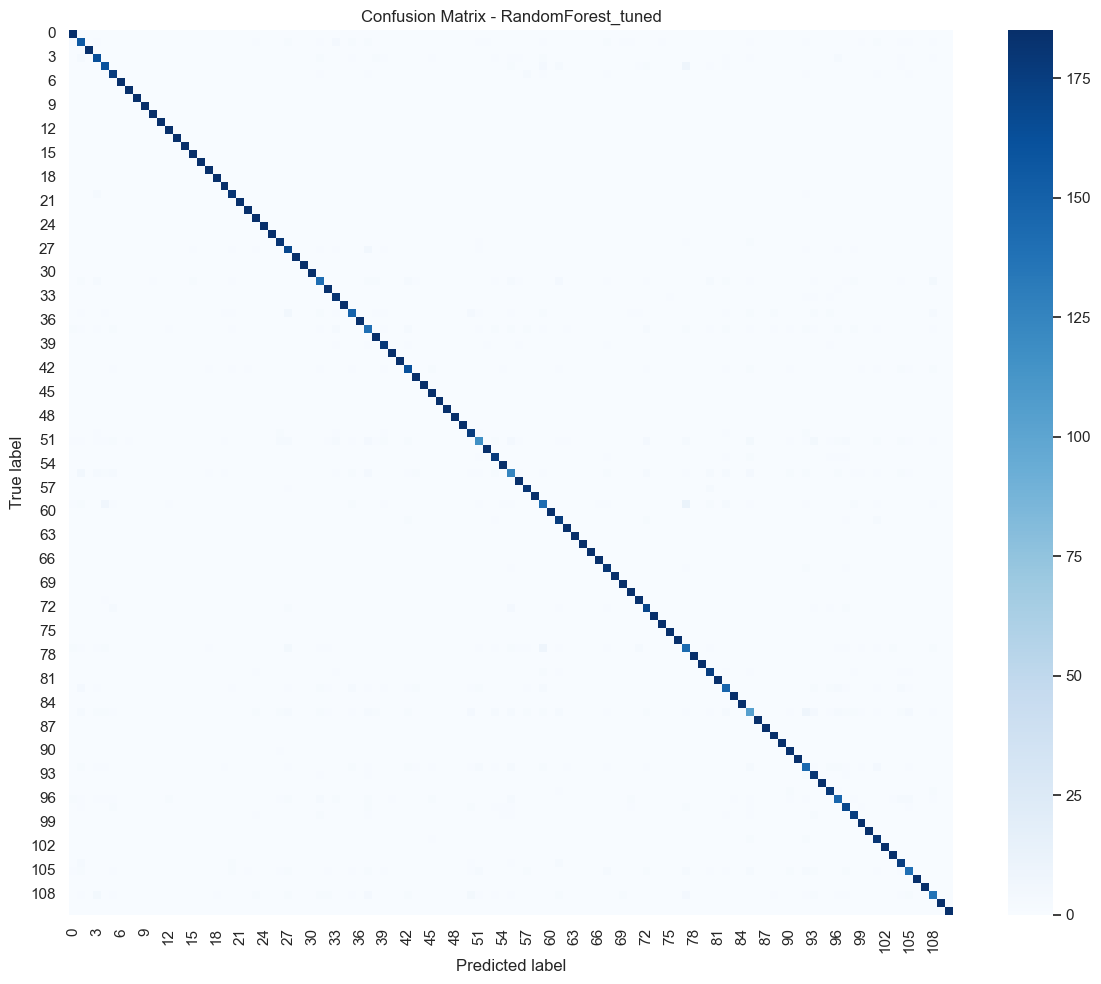

In [11]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print('Holdout test accuracy:', round(test_accuracy, 4))
print('Holdout test classification report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', square=False)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## Final Selection Note

The notebook selects the tuned model with the best 5-fold cross-validated macro F1-score, with accuracy used as the tie-breaker. If the two strongest models are close, prefer the one that is faster and easier to interpret for deployment.